In [1]:
import pandas as pd
from autoslo.workload_execution.execution_result import ExecutionResult
import os
from pathlib import Path
from tqdm import tqdm
from autoslo.filesystem.yaml_helpers import load_yaml
from autoslo.config.component_configs import AutoscalerConfig

from multiprocessing import Pool

In [2]:
def f(workload_dir):
    execution_result = ExecutionResult.load(workload_dir)  
    config_dir = workload_dir.parent

    config = load_yaml( workload_dir/ "execution_config.yml")
    autoscaler_config = AutoscalerConfig.from_config(config)

    return {
        "config": config_dir.name,
        "workload": workload_dir.name,
        "cost": execution_result.total_cost,  
            "slo_violation_rate": execution_result.violation_rate,
        "min_cluster_lifetime_s": autoscaler_config.min_cluster_lifetime_s,
        "idle_time_before_tear_down_s": autoscaler_config.idle_time_before_tear_down_s,
        "observation_window_s": autoscaler_config.observation_window_s,
        "min_observations_to_act": autoscaler_config.min_observations_to_act,
        "slo_tightening_factor": autoscaler_config.slo_tightening_factor,
        "min_finished_queries_in_counterfactual": autoscaler_config.min_finished_queries_in_counterfactual,
    }

In [3]:
base_dir = "/home/markakis/chunkbench/data/tuner_runs/main_eval_base__sampled_nocache_v2__KAPPA=4__LAST_DAY_DATE_INCLUSIVE=2024-05-26__NUM_DAYS=30__SLO_THRESHOLD=0.05__TARGET_DATE=2024-05-27/05_autoscaling_param_sweep/train"

In [4]:

tr_records = []
tr_workload_dirs = []

for config_dir in Path(base_dir).iterdir():
    if config_dir.is_dir():
        for workload_dir in config_dir.iterdir():
             if workload_dir.is_dir():
                tr_workload_dirs.append(workload_dir)

with Pool() as pool:
    tr_records = pool.map(f, tr_workload_dirs)

tr_df = pd.DataFrame(tr_records)


In [5]:
tr_df

,config,workload,cost,slo_violation_rate,min_cluster_lifetime_s,idle_time_before_tear_down_s,observation_window_s,min_observations_to_act,slo_tightening_factor,min_finished_queries_in_counterfactual
0,config_34,t_0__target__rf0.167,23.542083,0.021399,1200.0,1200.0,120.0,10,1.0,10
1,config_34,t_7__target__rf0.167,23.651250,0.031276,1200.0,1200.0,120.0,10,1.0,10
2,config_34,t_11__target__rf0.167,32.121667,0.018107,1200.0,1200.0,120.0,10,1.0,10
3,config_34,t_8__target__rf0.167,24.838333,0.007407,1200.0,1200.0,120.0,10,1.0,10
4,config_34,t_4__target__rf0.167,35.145000,0.041152,1200.0,1200.0,120.0,10,1.0,10
...,...,...,...,...,...,...,...,...,...,...
1147,config_54,t_9__target__rf0.167,39.087083,0.001646,3600.0,600.0,120.0,10,0.6,10
1148,config_54,t_6__target__rf0.167,17.149583,0.015638,3600.0,600.0,120.0,10,0.6,10
1149,config_54,t_5__target__rf0.167,17.818333,0.003292,3600.0,600.0,120.0,10,0.6,10
1150,config_54,t_10__target__rf0.167,17.300000,0.013992,3600.0,600.0,120.0,10,0.6,10


In [6]:
# For each of the 6 knobs, if we fix the value of the other 5 and the workload, how much variance is there
# in the SLO violation rate and cost? This will give us a sense of how much each knob matters, and which ones we should focus on tuning.
params = tr_df.columns[-6:]
targets = ["slo_violation_rate", "cost"]

results = {}

for target in targets:
    results[target] = {}

    for p in params:
        group_cols = ["workload"] + [x for x in params if x != p]

        results[target][p] = (
            tr_df.groupby(group_cols)[target].apply(lambda x: x.max() - x.min()).mean()
        )

results = pd.DataFrame(results)
print(results)

                                        slo_violation_rate      cost
min_cluster_lifetime_s                            0.002669  1.373838
idle_time_before_tear_down_s                      0.006207  2.082256
observation_window_s                              0.002421  3.647567
min_observations_to_act                           0.003952  2.190566
slo_tightening_factor                             0.022910  7.595173
min_finished_queries_in_counterfactual            0.001449  2.226573


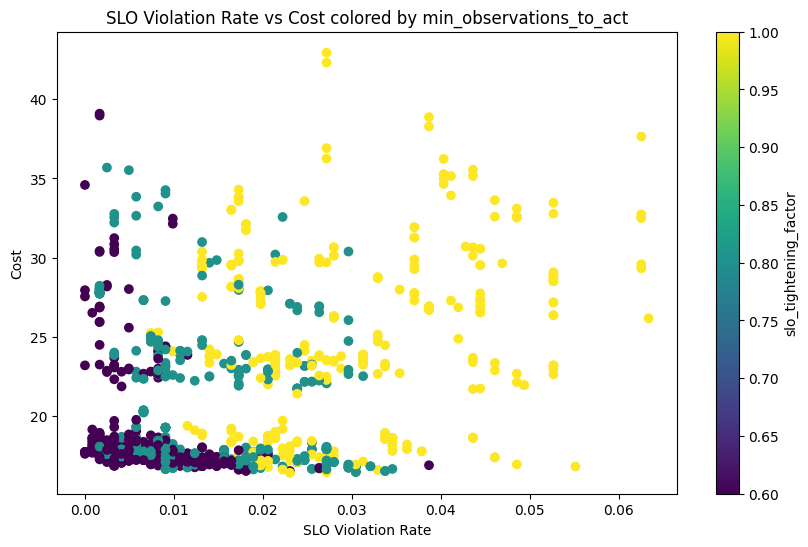

In [9]:
# Plot all points in a scatter plot of violation rate vs cost, color by
# the min_observations_to_act
import matplotlib.pyplot as plt

col = "slo_tightening_factor"

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    tr_df["slo_violation_rate"],
    tr_df["cost"],
    c=tr_df[col],
    cmap="viridis",
)
plt.colorbar(scatter, label=col)
plt.xlabel("SLO Violation Rate")
plt.ylabel("Cost")
plt.title("SLO Violation Rate vs Cost colored by min_observations_to_act")
plt.show()

In [8]:
# Train a small decision tree to predict SLO violation rate from the 6 knobs, and see which knobs are most important according to the tree.
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

X = tr_df[params]
y = tr_df["slo_violation_rate"] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

importances = model.feature_importances_
feature_importance_df = pd.DataFrame(
    {"feature": params, "importance": importances}
).sort_values(by="importance", ascending=False)
print(feature_importance_df)

Mean Squared Error: 8.354880779163006e-05
                                  feature  importance
4                   slo_tightening_factor    0.945103
1            idle_time_before_tear_down_s    0.035536
3                 min_observations_to_act    0.014404
2                    observation_window_s    0.004958
0                  min_cluster_lifetime_s    0.000000
5  min_finished_queries_in_counterfactual    0.000000


In [ ]:
# Interesting that the min lifetime seems so important. Are we that overeager to tear down?